In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

RANDOM_SEED = 42

# Locate the project root.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "diversevul_stratified_10000.csv"
)

print("SVM model development environment ready.")
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

SVM model development environment ready.
Project root: f:\BSc (Hons) in Cyber Security\Projects\NLP_Group_02
Dataset path: f:\BSc (Hons) in Cyber Security\Projects\NLP_Group_02\data\processed\diversevul_stratified_10000.csv
Dataset exists: True


In [2]:
# Train a Linear SVM classifier.
# Class balancing is used because vulnerable records are the minority class.

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    max_iter=10_000,
)

print("Training the Linear SVM model...")

svm_model.fit(
    X_train_tfidf,
    y_train,
)

print("Linear SVM training completed successfully.")

Training the Linear SVM model...


NameError: name 'X_train_tfidf' is not defined

In [2]:
# Load the processed working dataset.

svm_df = pd.read_csv(
    DATA_PATH,
    usecols=["func", "target"]
)

# Final validation before model development.
svm_df = svm_df.dropna(
    subset=["func", "target"]
).copy()

svm_df["func"] = svm_df["func"].astype(str)
svm_df["target"] = svm_df["target"].astype(int)

print("Dataset loaded successfully.")
print("Dataset shape:", svm_df.shape)

print("\nClass distribution:")
print(
    svm_df["target"]
    .value_counts()
    .sort_index()
)

print("\nMissing values:")
print(svm_df.isna().sum())

print("\nDuplicate source-code functions:")
print(svm_df["func"].duplicated().sum())

assert len(svm_df) == 10_000
assert set(svm_df["target"].unique()) == {0, 1}

print("\nDataset validation completed successfully.")

Dataset loaded successfully.
Dataset shape: (10000, 2)

Class distribution:
target
0    9409
1     591
Name: count, dtype: int64

Missing values:
func      0
target    0
dtype: int64

Duplicate source-code functions:
0

Dataset validation completed successfully.


In [3]:
# Separate the source code and target labels.

X = svm_df["func"]
y = svm_df["target"]

# First split:
# 70% training and 30% temporary data.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y,
)

# Second split:
# Divide temporary data equally into validation and testing sets.
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp,
)

print("Dataset split completed successfully.")

print("\nTraining set:")
print("Records:", len(X_train))
print(y_train.value_counts().sort_index())

print("\nValidation set:")
print("Records:", len(X_validation))
print(y_validation.value_counts().sort_index())

print("\nTesting set:")
print("Records:", len(X_test))
print(y_test.value_counts().sort_index())

print("\nTotal records after splitting:")
print(len(X_train) + len(X_validation) + len(X_test))

assert len(X_train) == 7000
assert len(X_validation) == 1500
assert len(X_test) == 1500
assert (
    len(X_train)
    + len(X_validation)
    + len(X_test)
    == len(svm_df)
)

print("\nSplit validation completed successfully.")

Dataset split completed successfully.

Training set:
Records: 7000
target
0    6586
1     414
Name: count, dtype: int64

Validation set:
Records: 1500
target
0    1411
1      89
Name: count, dtype: int64

Testing set:
Records: 1500
target
0    1412
1      88
Name: count, dtype: int64

Total records after splitting:
10000

Split validation completed successfully.


In [5]:
# Tokenise C/C++ source code into identifiers, numbers,
# operators and punctuation symbols.

import re

CODE_TOKEN_PATTERN = re.compile(
    r"""
    0x[0-9A-Fa-f]+
    |
    [A-Za-z_]\w*
    |
    \d+(?:\.\d+)?
    |
    ==|!=|<=|>=|->|\+\+|--|&&|\|\||<<|>>
    |
    [{}()\[\];,.+\-*/%&|^~!<>=?:]
    """,
    re.VERBOSE,
)


def code_tokenizer(source_code):
    """Convert one source-code function into code-related tokens."""
    return CODE_TOKEN_PATTERN.findall(str(source_code))


# Demonstrate the tokenizer using a short example.
example_code = """
int add_numbers(int a, int b) {
    return a + b;
}
"""

print("Example tokens:")
print(code_tokenizer(example_code))

Example tokens:
['int', 'add_numbers', '(', 'int', 'a', ',', 'int', 'b', ')', '{', 'return', 'a', '+', 'b', ';', '}']


In [6]:
# Convert source-code tokens into TF-IDF features.
# The vectoriser is fitted only on training data to prevent data leakage.

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=code_tokenizer,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=50_000,
    sublinear_tf=True,
    dtype=np.float32,
)

print("Fitting TF-IDF vectoriser on training data...")

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

print("Transforming validation data...")
X_validation_tfidf = tfidf_vectorizer.transform(X_validation)

print("Transforming testing data...")
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\nTF-IDF feature extraction completed successfully.")

print("\nTraining feature shape:")
print(X_train_tfidf.shape)

print("\nValidation feature shape:")
print(X_validation_tfidf.shape)

print("\nTesting feature shape:")
print(X_test_tfidf.shape)

print("\nVocabulary size:")
print(len(tfidf_vectorizer.vocabulary_))

assert X_train_tfidf.shape[0] == 7000
assert X_validation_tfidf.shape[0] == 1500
assert X_test_tfidf.shape[0] == 1500

print("\nTF-IDF validation completed successfully.")

Fitting TF-IDF vectoriser on training data...
Transforming validation data...
Transforming testing data...

TF-IDF feature extraction completed successfully.

Training feature shape:
(7000, 50000)

Validation feature shape:
(1500, 50000)

Testing feature shape:
(1500, 50000)

Vocabulary size:
50000

TF-IDF validation completed successfully.


In [7]:
# Train a Linear SVM classifier.
# Class balancing is used because vulnerable records are the minority class.

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    max_iter=10_000,
)

print("Training the Linear SVM model...")

svm_model.fit(
    X_train_tfidf,
    y_train,
)

print("Linear SVM training completed successfully.")

Training the Linear SVM model...
Linear SVM training completed successfully.


In [8]:
# Generate predictions for the validation set.

y_validation_pred = svm_model.predict(
    X_validation_tfidf
)

validation_accuracy = accuracy_score(
    y_validation,
    y_validation_pred,
)

validation_precision = precision_score(
    y_validation,
    y_validation_pred,
    zero_division=0,
)

validation_recall = recall_score(
    y_validation,
    y_validation_pred,
    zero_division=0,
)

validation_f1 = f1_score(
    y_validation,
    y_validation_pred,
    zero_division=0,
)

print("Validation evaluation completed successfully.")

print(f"\nAccuracy:  {validation_accuracy:.4f}")
print(f"Precision: {validation_precision:.4f}")
print(f"Recall:    {validation_recall:.4f}")
print(f"F1-score:  {validation_f1:.4f}")

print("\nDetailed classification report:")
print(
    classification_report(
        y_validation,
        y_validation_pred,
        target_names=[
            "Non-vulnerable",
            "Vulnerable",
        ],
        zero_division=0,
    )
)

Validation evaluation completed successfully.

Accuracy:  0.9253
Precision: 0.2444
Recall:    0.1236
F1-score:  0.1642

Detailed classification report:
                precision    recall  f1-score   support

Non-vulnerable       0.95      0.98      0.96      1411
    Vulnerable       0.24      0.12      0.16        89

      accuracy                           0.93      1500
     macro avg       0.60      0.55      0.56      1500
  weighted avg       0.90      0.93      0.91      1500



Validation confusion matrix:
[[1377   34]
 [  78   11]]

True negatives: 1377
False positives: 34
False negatives: 78
True positives: 11


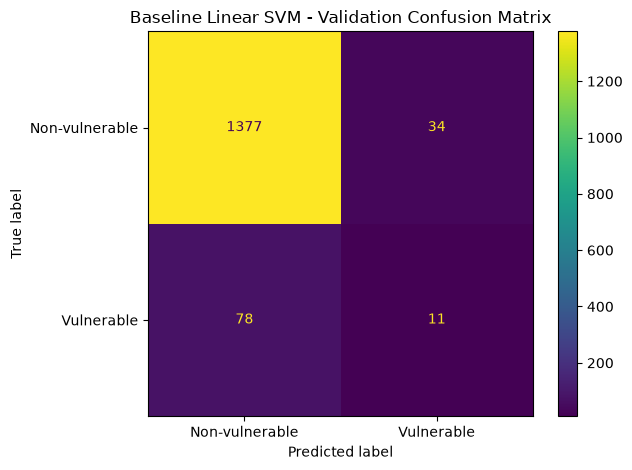

In [9]:
# Display the validation confusion matrix.

validation_cm = confusion_matrix(
    y_validation,
    y_validation_pred,
)

tn, fp, fn, tp = validation_cm.ravel()

print("Validation confusion matrix:")
print(validation_cm)

print("\nTrue negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

ConfusionMatrixDisplay(
    confusion_matrix=validation_cm,
    display_labels=[
        "Non-vulnerable",
        "Vulnerable",
    ],
).plot(
    values_format="d",
)

plt.title("Baseline Linear SVM - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [10]:
# Tune the SVM regularisation parameter using only the validation set.

C_VALUES = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]

tuning_results = []
candidate_models = {}

print("Starting SVM hyperparameter tuning...\n")

for c_value in C_VALUES:
    candidate_model = LinearSVC(
        C=c_value,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        max_iter=10_000,
    )

    candidate_model.fit(
        X_train_tfidf,
        y_train,
    )

    candidate_predictions = candidate_model.predict(
        X_validation_tfidf
    )

    candidate_precision = precision_score(
        y_validation,
        candidate_predictions,
        zero_division=0,
    )

    candidate_recall = recall_score(
        y_validation,
        candidate_predictions,
        zero_division=0,
    )

    candidate_f1 = f1_score(
        y_validation,
        candidate_predictions,
        zero_division=0,
    )

    tuning_results.append(
        {
            "C": c_value,
            "Precision": candidate_precision,
            "Recall": candidate_recall,
            "F1-score": candidate_f1,
        }
    )

    candidate_models[c_value] = candidate_model

tuning_results_df = pd.DataFrame(
    tuning_results
).sort_values(
    by="F1-score",
    ascending=False,
).reset_index(drop=True)

print("SVM tuning completed successfully.\n")
print(tuning_results_df.to_string(index=False))

best_c = tuning_results_df.loc[0, "C"]
best_validation_f1 = tuning_results_df.loc[0, "F1-score"]

print(f"\nBest C value: {best_c}")
print(f"Best validation F1-score: {best_validation_f1:.4f}")

tuned_svm_model = candidate_models[best_c]

Starting SVM hyperparameter tuning...

SVM tuning completed successfully.

   C  Precision   Recall  F1-score
0.05   0.147186 0.382022  0.212500
0.25   0.208791 0.213483  0.211111
0.01   0.128342 0.539326  0.207343
0.10   0.151515 0.280899  0.196850
2.00   0.272727 0.134831  0.180451
0.50   0.209677 0.146067  0.172185
1.00   0.244444 0.123596  0.164179
5.00   0.243243 0.101124  0.142857

Best C value: 0.05
Best validation F1-score: 0.2125


In [14]:
# Tune the decision threshold using only the validation set.
# The testing set remains untouched.

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
)

validation_scores = tuned_svm_model.decision_function(
    X_validation_tfidf
)

precision_values, recall_values, threshold_values = (
    precision_recall_curve(
        y_validation,
        validation_scores,
    )
)

# The final precision and recall values do not have a matching threshold.
threshold_precision = precision_values[:-1]
threshold_recall = recall_values[:-1]

f1_values = np.divide(
    2 * threshold_precision * threshold_recall,
    threshold_precision + threshold_recall,
    out=np.zeros_like(threshold_precision),
    where=(threshold_precision + threshold_recall) != 0,
)

best_threshold_index = np.argmax(f1_values)

best_threshold = threshold_values[best_threshold_index]
best_threshold_precision = threshold_precision[best_threshold_index]
best_threshold_recall = threshold_recall[best_threshold_index]
best_threshold_f1 = f1_values[best_threshold_index]

average_precision = average_precision_score(
    y_validation,
    validation_scores,
)

optimized_validation_predictions = (
    validation_scores >= best_threshold
).astype(int)

optimized_validation_cm = confusion_matrix(
    y_validation,
    optimized_validation_predictions,
)

print("Decision-threshold tuning completed successfully.")

print(f"\nSelected C value: {best_c}")
print(f"Best decision threshold: {best_threshold:.4f}")
print(f"Precision: {best_threshold_precision:.4f}")
print(f"Recall: {best_threshold_recall:.4f}")
print(f"F1-score: {best_threshold_f1:.4f}")
print(f"Average precision: {average_precision:.4f}")

print("\nOptimized validation confusion matrix:")
print(optimized_validation_cm)

Decision-threshold tuning completed successfully.

Selected C value: 0.05
Best decision threshold: -0.0693
Precision: 0.1509
Recall: 0.5393
F1-score: 0.2359
Average precision: 0.1843

Optimized validation confusion matrix:
[[1141  270]
 [  41   48]]


In [15]:
# Evaluate the selected SVM model and threshold on the untouched test set.

from sklearn.metrics import roc_auc_score

test_scores = tuned_svm_model.decision_function(
    X_test_tfidf
)

optimized_test_predictions = (
    test_scores >= best_threshold
).astype(int)

test_accuracy = accuracy_score(
    y_test,
    optimized_test_predictions,
)

test_precision = precision_score(
    y_test,
    optimized_test_predictions,
    zero_division=0,
)

test_recall = recall_score(
    y_test,
    optimized_test_predictions,
    zero_division=0,
)

test_f1 = f1_score(
    y_test,
    optimized_test_predictions,
    zero_division=0,
)

test_average_precision = average_precision_score(
    y_test,
    test_scores,
)

test_roc_auc = roc_auc_score(
    y_test,
    test_scores,
)

optimized_test_cm = confusion_matrix(
    y_test,
    optimized_test_predictions,
)

print("Final SVM test evaluation completed successfully.")

print(f"\nSelected C value: {best_c}")
print(f"Selected decision threshold: {best_threshold:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"Average precision: {test_average_precision:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")

print("\nDetailed test classification report:")
print(
    classification_report(
        y_test,
        optimized_test_predictions,
        target_names=[
            "Non-vulnerable",
            "Vulnerable",
        ],
        zero_division=0,
    )
)

print("\nOptimized test confusion matrix:")
print(optimized_test_cm)

Final SVM test evaluation completed successfully.

Selected C value: 0.05
Selected decision threshold: -0.0693
Accuracy: 0.7833
Precision: 0.1262
Recall: 0.4545
F1-score: 0.1975
Average precision: 0.1937
ROC-AUC: 0.7139

Detailed test classification report:
                precision    recall  f1-score   support

Non-vulnerable       0.96      0.80      0.87      1412
    Vulnerable       0.13      0.45      0.20        88

      accuracy                           0.78      1500
     macro avg       0.54      0.63      0.54      1500
  weighted avg       0.91      0.78      0.84      1500


Optimized test confusion matrix:
[[1135  277]
 [  48   40]]


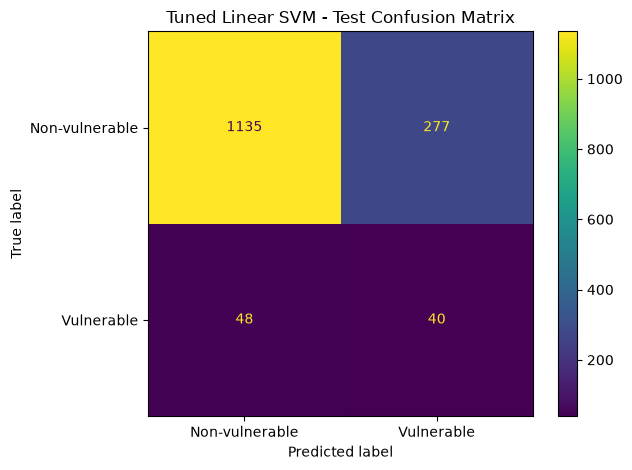

In [16]:
# Display the final test confusion matrix.

ConfusionMatrixDisplay(
    confusion_matrix=optimized_test_cm,
    display_labels=[
        "Non-vulnerable",
        "Vulnerable",
    ],
).plot(
    values_format="d",
)

plt.title("Tuned Linear SVM - Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
# Save the trained SVM artifacts and final evaluation metrics.

import json

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = (
    MODELS_DIR
    / "CIT-24-01-0251_svm_model_bundle.joblib"
)

METRICS_PATH = (
    REPORTS_DIR
    / "CIT-24-01-0251_svm_metrics.json"
)

svm_model_bundle = {
    "model": tuned_svm_model,
    "vectorizer": tfidf_vectorizer,
    "decision_threshold": float(best_threshold),
    "selected_c": float(best_c),
    "class_labels": {
        0: "Non-vulnerable",
        1: "Vulnerable",
    },
}

joblib.dump(
    svm_model_bundle,
    MODEL_PATH,
)

svm_metrics = {
    "student_id": "CIT-24-01-0251",
    "model": "Linear Support Vector Machine",
    "feature_extraction": "TF-IDF with code tokenization",
    "dataset_size": int(len(svm_df)),
    "training_records": int(len(X_train)),
    "validation_records": int(len(X_validation)),
    "testing_records": int(len(X_test)),
    "selected_c": float(best_c),
    "decision_threshold": float(best_threshold),
    "test_accuracy": float(test_accuracy),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1_score": float(test_f1),
    "test_average_precision": float(test_average_precision),
    "test_roc_auc": float(test_roc_auc),
    "test_confusion_matrix": optimized_test_cm.tolist(),
}

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as metrics_file:
    json.dump(
        svm_metrics,
        metrics_file,
        indent=4,
    )

print("SVM artifacts saved successfully.")

print("\nModel bundle:")
print(MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

print("\nMetrics report:")
print(METRICS_PATH)
print("Metrics report exists:", METRICS_PATH.exists())

SVM artifacts saved successfully.

Model bundle:
f:\BSc (Hons) in Cyber Security\Projects\NLP_Group_02\models\CIT-24-01-0251_svm_model_bundle.joblib
Model exists: True

Metrics report:
f:\BSc (Hons) in Cyber Security\Projects\NLP_Group_02\reports\CIT-24-01-0251_svm_metrics.json
Metrics report exists: True
